In [5]:
# 1. Instalación estable (evitamos git para prevenir conflictos de caché)
!pip install -q "transformers[torch]" decord accelerate

import torch
import numpy as np
from transformers import AutoImageProcessor, VideoMAEForVideoClassification

# Usamos VideoMAE: Es más robusto en Colab y excelente para detectar anomalías/delitos
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"

print("Cargando procesador y modelo...")
processor = AutoImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

def clasificar_comportamiento_video(video_frames):
    """
    Entrada: Secuencia de frames (tensores o numpy)
    Salida: Etiqueta de la acción detectada
    """
    # El modelo espera una lista de frames procesados
    inputs = processor(list(video_frames), return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    predicted_label = logits.argmax(-1).item()
    return model.config.id2label[predicted_label]

print(f"Modelo {model.__class__.__name__} configurado y listo para pruebas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 47.0 MB/s eta 0:00:00


ImportError: cannot import name 'merge_with_config_defaults' from 'transformers.utils.generic' (/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py)

In [6]:
# 1. Desinstalamos la versión corrupta y fijamos una versión estable
!pip uninstall -y transformers
!pip install -q transformers==4.37.2 evaluate av decord

print("================================================================")
print("ALERTA: Debes reiniciar el entorno de ejecución AHORA MISMO.")
print("Ve al menú superior: Entorno de ejecución -> Reiniciar sesión")
print("(O usa el atajo: Ctrl + M + . )")
print("================================================================")

Found existing installation: transformers 5.6.0.dev0
Uninstalling transformers-5.6.0.dev0:
  Successfully uninstalled transformers-5.6.0.dev0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 49.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.37.2 which is incompatible.
ALERTA: Debes reiniciar el entorno de ejecución AHORA MISMO.
Ve al menú superior: Entorno de ejecución -> Reiniciar sesión
(O usa el atajo: Ctrl + M + . )


In [1]:
import torch
import numpy as np
from transformers import AutoImageProcessor, VideoMAEForVideoClassification

# Cargamos el modelo alternativo preentrenado (Ruta C)
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"

print("Descargando pesos del modelo (esto puede tardar un par de minutos)...")
processor = AutoImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(model_ckpt)

def clasificar_comportamiento_video(video_frames):
    """
    Función de prueba para el prototipo avanzado.
    """
    inputs = processor(list(video_frames), return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    predicted_label = logits.argmax(-1).item()
    return model.config.id2label[predicted_label]

print(f"¡Éxito! Modelo {model.__class__.__name__} configurado y listo para inferencia.")

Descargando pesos del modelo (esto puede tardar un par de minutos)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

¡Éxito! Modelo VideoMAEForVideoClassification configurado y listo para inferencia.


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:00


--- INICIANDO ANÁLISIS DE IMAGEN ---

image 1/1 /content/WhatsApp Image 2026-04-10 at 7.31.54 PM.jpeg: 640x480 2 buss, 780.8ms
Speed: 20.7ms preprocess, 780.8ms inference, 7.5ms postprocess per image at shape (1, 3, 640, 480)
Resultado de la imagen:


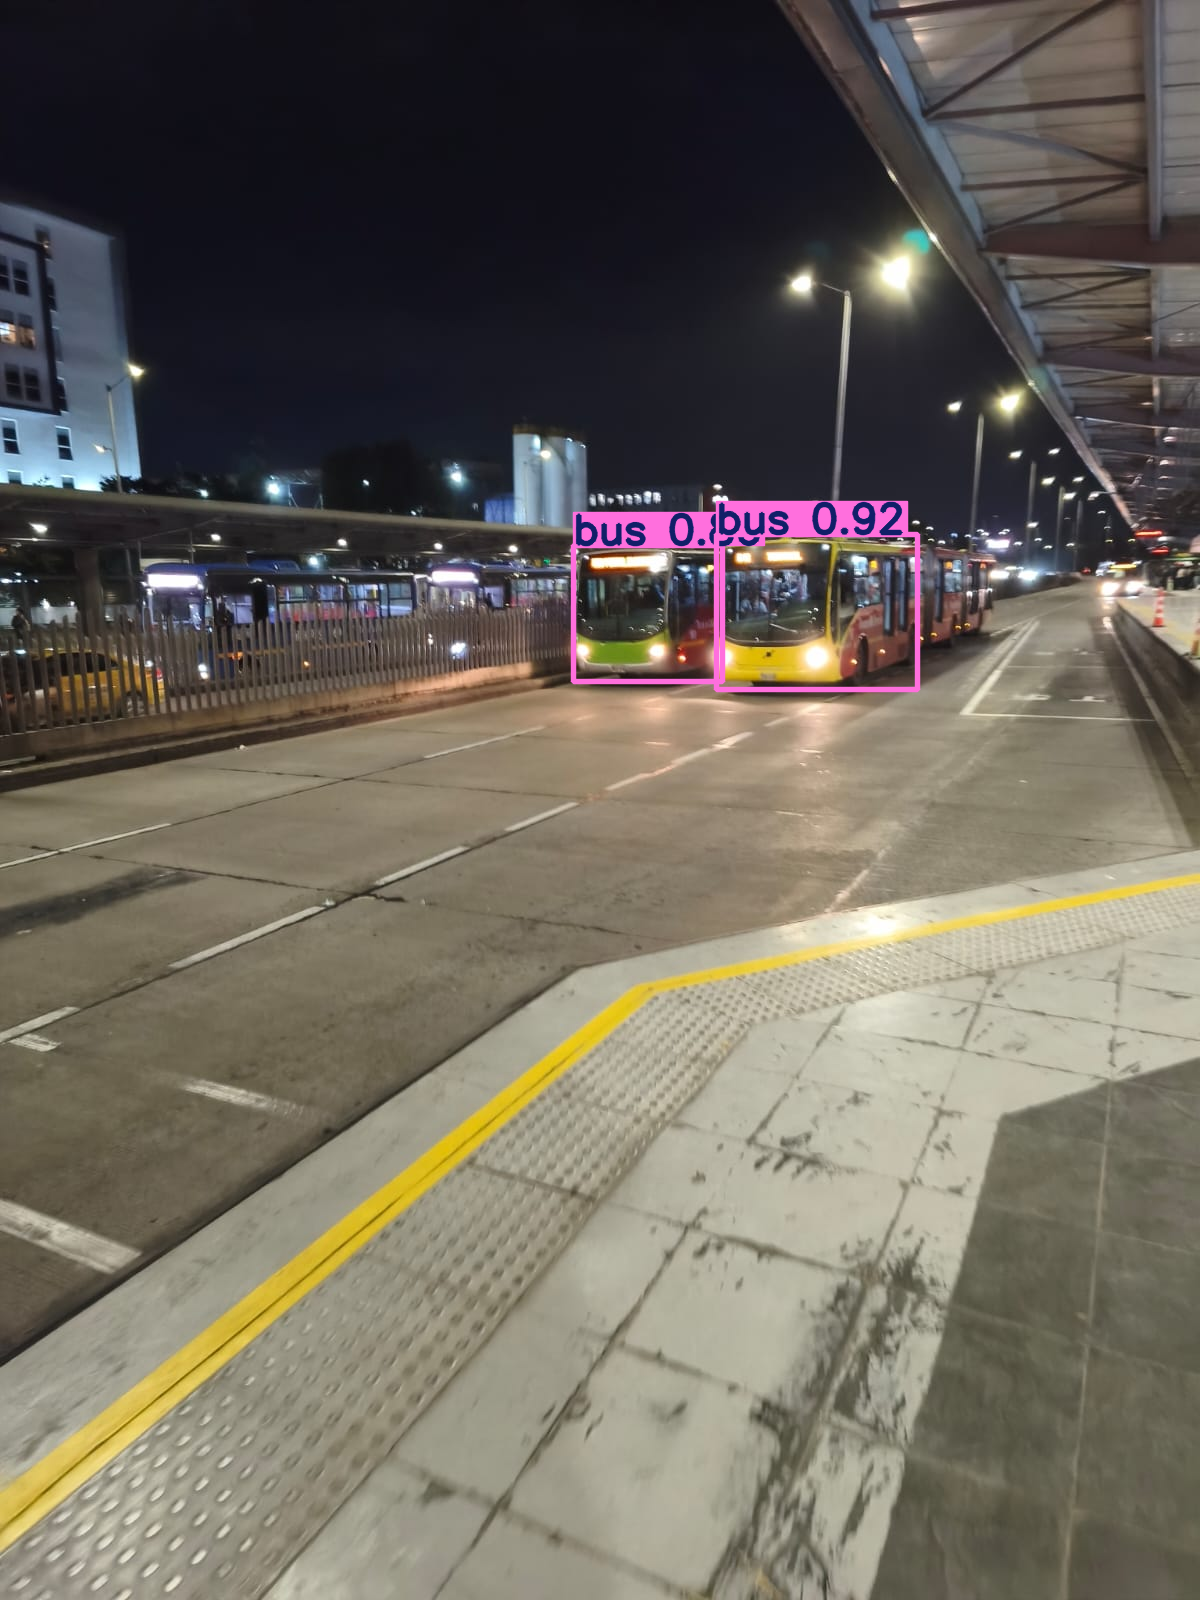


--- INICIANDO ANÁLISIS DE VIDEO ---
Procesando video a 30 FPS. Esto tomará unos momentos...
Procesados 30 frames...
Procesados 60 frames...
Procesados 90 frames...
Procesados 120 frames...
Procesados 150 frames...
Procesados 180 frames...
Procesados 210 frames...
Procesados 240 frames...
Procesados 270 frames...
Procesados 300 frames...
Procesados 330 frames...
✅ Análisis de video completado. Archivo guardado como: resultado_video_analizado.mp4
Puedes descargar 'resultado_video_analizado.mp4' desde la pestaña de archivos en Colab.


In [5]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# 1. Cargar el modelo Baseline
model = YOLO('yolov8n.pt')

# Nombres exactos de los archivos subidos
ruta_imagen = 'WhatsApp Image 2026-04-10 at 7.31.54 PM.jpeg' # Verifica si es .jpg o .jpeg
ruta_video_entrada = 'WhatsApp Video 2026-04-10 at 7.31.53 PM.mp4'
ruta_video_salida = 'resultado_video_analizado.mp4'

print("--- INICIANDO ANÁLISIS DE IMAGEN ---")
try:
    # Inferencia en la imagen de WhatsApp
    resultados_img = model.predict(source=ruta_imagen, conf=0.35)
    img_analizada = resultados_img[0].plot()

    print("Resultado de la imagen:")
    cv2_imshow(img_analizada)
except Exception as e:
    print(f"Error procesando la imagen. Verifica el nombre exacto y extensión: {e}")

print("\n--- INICIANDO ANÁLISIS DE VIDEO ---")
try:
    # Configuración de lectura de video
    cap = cv2.VideoCapture(ruta_video_entrada)

    # Propiedades del video original
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    # Configuración de escritura de video de salida
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(ruta_video_salida, fourcc, fps, (width, height))

    frame_count = 0
    print(f"Procesando video a {fps} FPS. Esto tomará unos momentos...")

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break # Fin del video

        # Inferencia frame a frame
        resultados_frame = model.predict(frame, conf=0.4, verbose=False)
        frame_procesado = resultados_frame[0].plot()

        # Escribir el frame en el nuevo archivo
        out.write(frame_procesado)

        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Procesados {frame_count} frames...")

    cap.release()
    out.release()
    print(f"✅ Análisis de video completado. Archivo guardado como: {ruta_video_salida}")
    print("Puedes descargar 'resultado_video_analizado.mp4' desde la pestaña de archivos en Colab.")

except Exception as e:
    print(f"Error procesando el video. Verifica el nombre exacto: {e}")